<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


**<h1>Mean Shift Clustering </h1>**


## **Introduction**
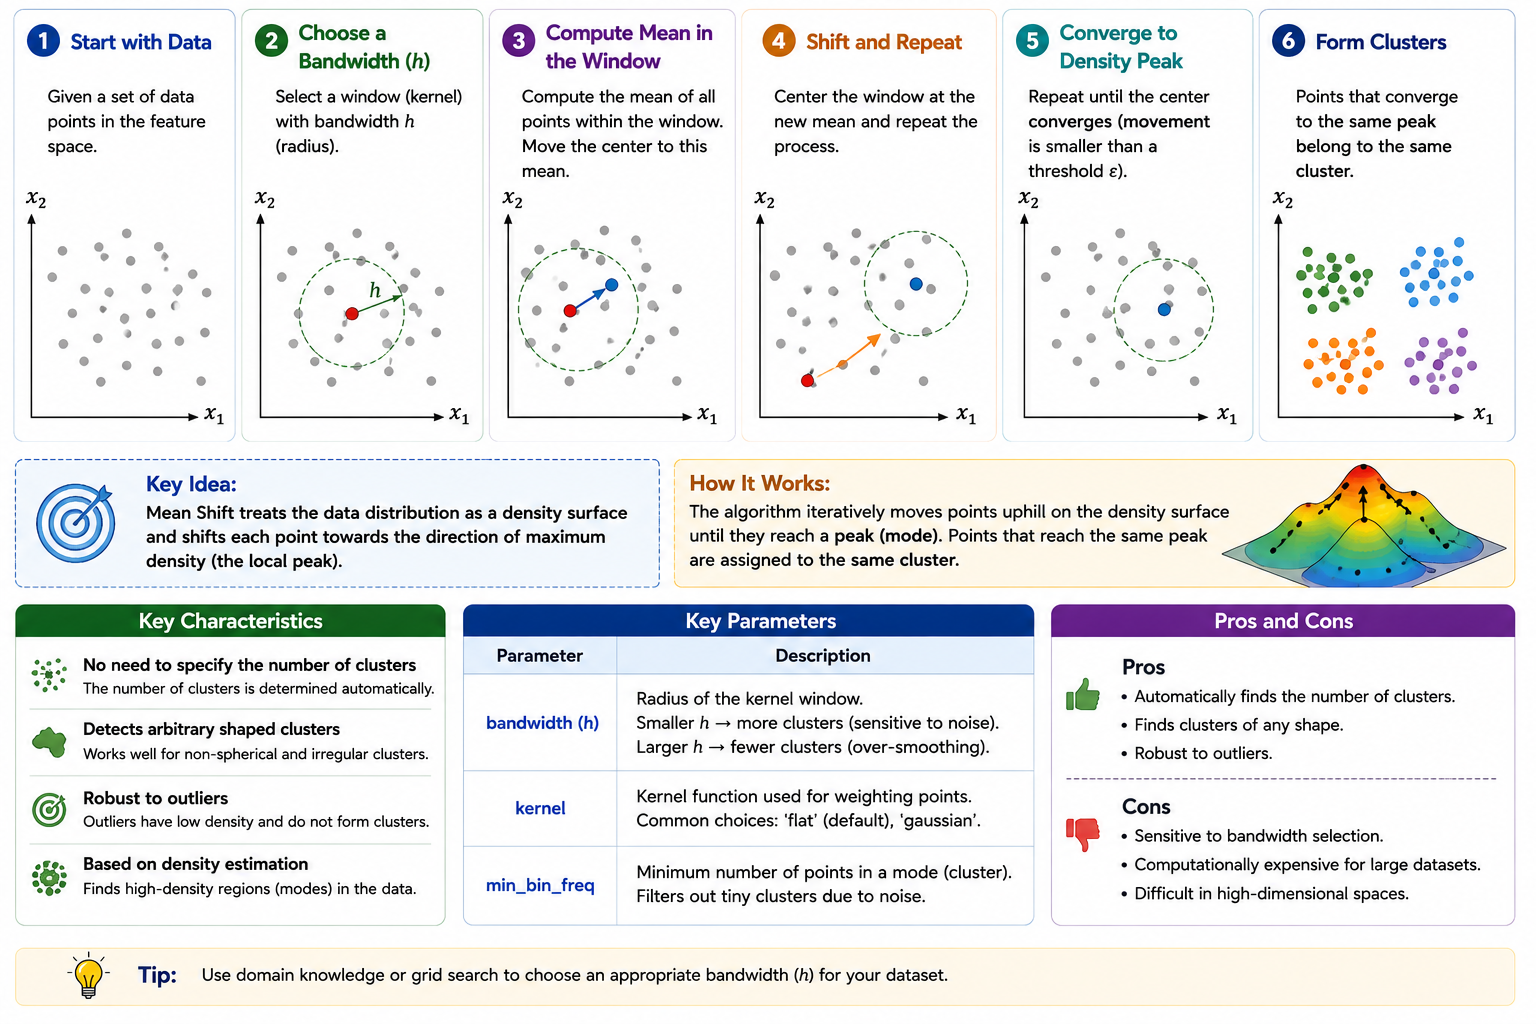

Suppose you are hiking in the mountains and notice several plants you have not seen before. Although you may not know their exact species, you can observe that some plants share similar features, such as color, shape, or size. These similarities suggest that the plants may belong to related groups.

This is the type of pattern that clustering analysis is designed to identify. Clustering groups observations based on shared characteristics, allowing similar objects to be organized together even when no labels are available.


## **Workflow**
In this notebook, we will explore Mean Shift Clustering, a **non-parametric, centroid-based clustering** algorithm. Mean Shift groups unlabeled data by locating dense regions in the feature space and assigning nearby observations to the same cluster. Unlike K-Means, Mean Shift does not require the number of clusters to be specified in advance, which makes it useful when the natural grouping structure is unknown. Common applications include image segmentation, search and recommendation systems, medical analysis, and other tasks that rely on discovering patterns in unlabeled data.

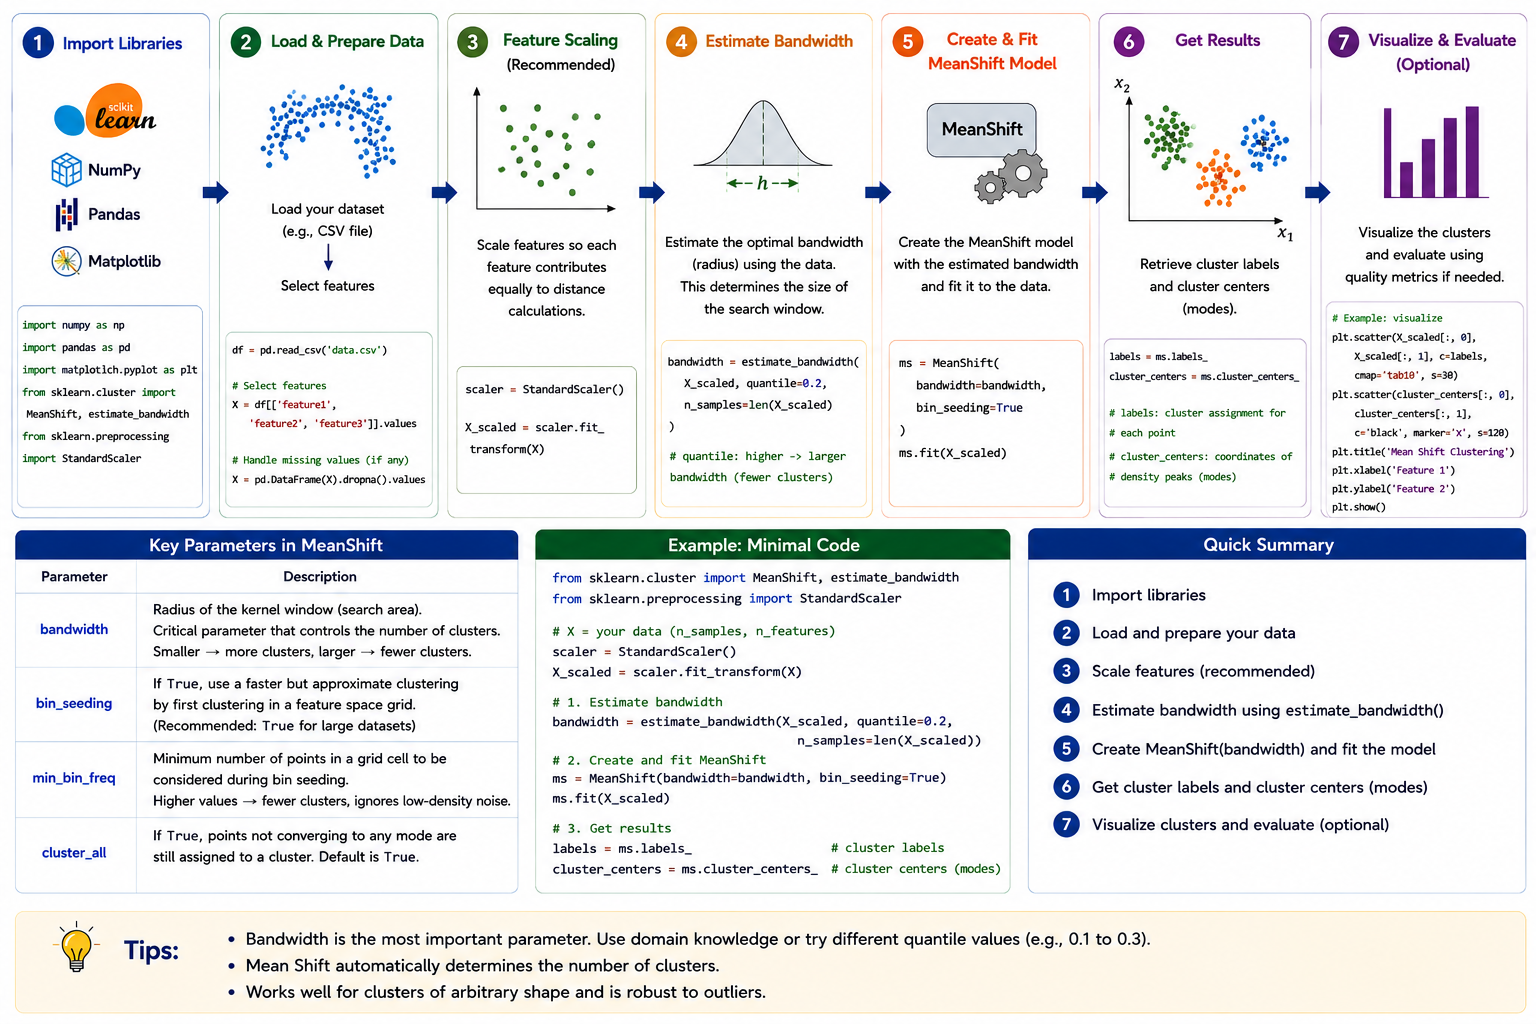

In the first part of this notebook, we will apply Mean Shift to image segmentation. Image segmentation groups pixels with similar characteristics, such as color or intensity, which can simplify an image and make object boundaries easier to identify.

In the second part, we will apply Mean Shift to the Titanic dataset. Using passenger features such as age, ticket class, fare, and other available attributes, we will group passengers into clusters and then examine how survival outcomes vary across those groups.


## __Table of Contents__

1. [Objectives](<#Objectives>)
2. [Setup](<#Setup>)
    1. [Installing Required Libraries](<#Installing-Required-Libraries>)
    2. [Importing Required Libraries](<#Importing-Required-Libraries>)
3. [Mean Shift for Image Segmentation](<#Mean-Shift-for-Image-Segmentation>)
    1. [Pre-processing Image](<#Pre-processing-Image>)
    2. [Apply Mean Shift to the Image](<#Apply-Mean-Shift-to-the-Image>)
4. [Exercises](<#Exercises>)
    1. [Exercise 1 - Repeat the above image segmentation process for a new image on the internet](<#Exercise-1---Repeat-the-above-image-segmentation-process-for-a-new-image-on-the-internet>)
    2. [Exercise 2 - Mean Shift Applied to the Titanic Dataset](<#Exercise-2---Mean-Shift-Applied-to-the-Titanic-Dataset>)
5. [How Mean Shift Works (Optional)](<#How-Mean-Shift-Works-(Optional)>)
    1. [Kernel Density Estimation](<#Kernel-Density-Estimation>)
    2. [Mean Shift From Scratch](<#Mean-Shift-From-Scratch>)


----


## **Objectives**


After completing this lab you will be able to:


- **Understand** Kernel Density Estimation (KDE).
- **Describe** how Mean Shift Works from scratch.
- **Implement** Mean Shift for image segmentation.


## **Setup**


For this lab, we will be using the following libraries:
 - [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01) for managing the data.
 - [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01) for mathematical operations.
 - [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01) for machine learning and machine-learning-pipeline related functions.
 - [`openCV`](https://opencv.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01) OpenCV provides a real-time optimized Computer Vision library, tools, and hardware. 
 - [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01) for additional plotting tools.


### **Installing Required Libraries**

The following required modules are pre-installed in the Skills Network Labs environment. However if you run this notebook commands in a different Jupyter environment (e.g. Watson Studio or Ananconda) you will need to install these libraries by removing the `#` sign before `!mamba` in the code cell below.


In [106]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
#!mamba install -qy pandas==1.3.4 numpy==1.21.4 matplotlib==3.5.0 scikit-learn==0.20.1 scipy==1.7.3
# Note: If your environment doesn't support "!mamba install", use "!pip install pandas==1.3.4 numpy==1.21.4 matplotlib==3.5.0 scikit-learn==0.20.1 scipy==1.7.3"

In [107]:
#!pip install opencv-python

### **Importing Required Libraries**


In [108]:
# Suppress any warnings:
import warnings
from urllib.request import urlopen, urlretrieve
import math

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from mpl_toolkits import mplot3d
from PIL import Image
from sklearn.cluster import MeanShift, estimate_bandwidth


def warn(*args, **kwargs):
    pass


warnings.warn = warn

If you wish to learn in detail about how Mean Shift works before studying its applications, you can go to [How Mean Shift Works (Optional)](<#How-Mean-Shift-Works-(Optional)>) section first.


## **Mean Shift for Image Segmentation**


### **Pre-processing Image**


Mean Shift Clustering can be used for image segmentation. An image segmentation attempts to cluster an image pixels according to their color. It then replaces each pixel's color with the mean color of its cluster. This way considerably reduces the number of different colors in the image. So, each cluster represents the mode or the most common intensities. Every pixel is labeled according to the cluster it’s nearest to. Consider the following image.


Download the image:


In [109]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%202/peppers.jpeg"
urlretrieve(url, "peppers.jpeg")

('peppers.jpeg', <http.client.HTTPMessage at 0x78e3287d3040>)

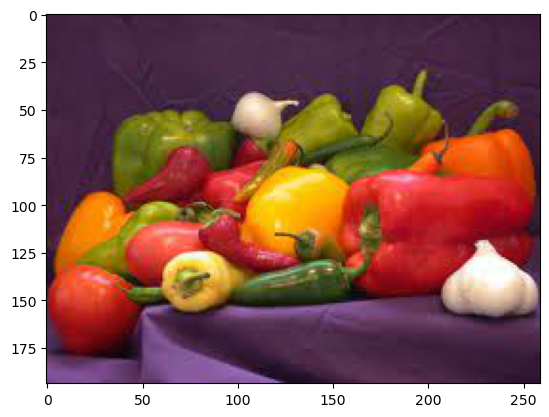

In [ ]:
img = cv.imread("peppers.jpeg")
plt.imshow(
    cv.cvtColor(img, cv.COLOR_BGR2RGB)
)  # Display the image using Matplotlib (convert from BGR to RGB)
plt.show()

We will pre-process the image by smoothing it.  


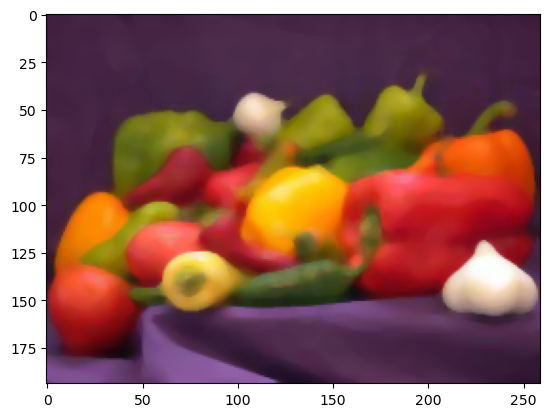

In [ ]:
img = cv.medianBlur(
    img, 7
)  # Apply median blur to reduce noise and smooth the image
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))

We can plot the Red, Green, Blue (RGB) values as 3D points. 


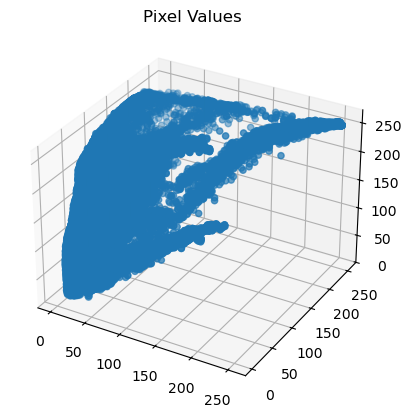

In [112]:
ax = plt.axes(projection="3d")
ax.scatter3D(img[:, :, 0], img[:, :, 1], img[:, :, 2])
ax.set_title("Pixel Values ")
plt.show()

We have a rectangular image with three channels.   


In [113]:
img.shape

(194, 259, 3)

We convert the image to 194 x 259 rows (194 x 259 = 50246, which is the shape of our matrix) for each pixel, and three columns for each color channel (Red, Green, Blue), as a numpy array of <code>X</code>:


In [114]:
X = img.reshape((-1, 3))
print("shape: ", X.shape)
print("data type   : ", X.dtype)

shape:  (50246, 3)
data type   :  uint8


As we see, the data type is `unit8`, so, we need to cast it to be a `float32`:


In [115]:
X = np.float32(X)

### **Apply Mean Shift to the Image**


Estimate the bandwidth to use with the mean-shift algorithm, using the <code>estimate_bandwidth</code> function:
- <code>X</code>: array-like of shape <code>(n_samples, n_features)</code>
Input points.
- <code>quantile</code>: float, default=0.3 Should be between [0, 1], 0.5 means that the median of all pairwise distances is used.
- <code>n_samples</code>: int, The number of samples to be used. If not given, all samples are to be used.


In [ ]:
bandwidth = estimate_bandwidth(X, quantile=0.06, n_samples=3000)
bandwidth

33.52662811577077

We can create a <code>MeanShift</code> object in sklearn with the following parameters:
- <code>bandwidth</code>:float, default=None
Bandwidth used in the RBF kernel.
- <code>max_itert</code>: (default=300) Maximum number of iterations per seed point before the clustering operation terminates (for that seed point), if has not converged yet.
- <code>bin_seeding</code> :if true, initial kernel locations are not locations of all points, but rather the location of the discretized version of points.

We then fit the model.


In [ ]:
ms = MeanShift(
    bandwidth=bandwidth, bin_seeding=True
)  # Create a MeanShift object with the estimated bandwidth and bin seeding enabled
ms.fit(X)

,bandwidth,33.52662811577077
,seeds,None
,bin_seeding,True
,min_bin_freq,1
,cluster_all,True
,n_jobs,None
,max_iter,300


Now, we have the label corresponding to the label of each row.


In [ ]:
labeled = (
    ms.labels_
)  # Get the labels assigned to each pixel by the MeanShift algorithm
labeled

array([0, 0, 0, ..., 0, 0, 0])

For each sample, we can find the assigned clusters:


In [119]:
clusters = ms.predict(X)
clusters

array([0, 0, 0, ..., 0, 0, 0])

We can list the unique clusters.  


In [120]:
np.unique(labeled)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

We can also list the actual cluster centroid locations, which are also the RGB values:


In [121]:
ms.cluster_centers_

array([[ 67.290054,  37.910378,  70.047585],
       [ 32.465878,  28.873552, 173.61473 ],
       [ 25.353125,  94.19406 ,  97.505   ],
       [ 24.220963, 130.9818  , 141.22623 ],
       [138.77016 ,  78.833244, 123.05814 ],
       [ 11.087073, 108.30878 , 237.65907 ],
       [  8.354187, 182.78345 , 251.84216 ],
       [188.98425 , 214.58464 , 239.97244 ],
       [156.90855 , 184.08748 , 216.2505  ],
       [239.8282  , 246.82051 , 251.05128 ],
       [ 91.85625 , 217.33438 , 250.06876 ]], dtype=float32)

We can convert the clusters `unit8` datatype for images: 


In [122]:
cluster_int8 = np.uint8(ms.cluster_centers_)
cluster_int8

array([[ 67,  37,  70],
       [ 32,  28, 173],
       [ 25,  94,  97],
       [ 24, 130, 141],
       [138,  78, 123],
       [ 11, 108, 237],
       [  8, 182, 251],
       [188, 214, 239],
       [156, 184, 216],
       [239, 246, 251],
       [ 91, 217, 250]], dtype=uint8)

We can also estimate what cluster each sample belongs to, as follows: 


In [123]:
ms.predict(X)

array([0, 0, 0, ..., 0, 0, 0])

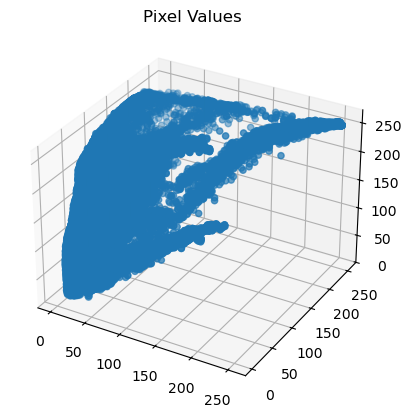

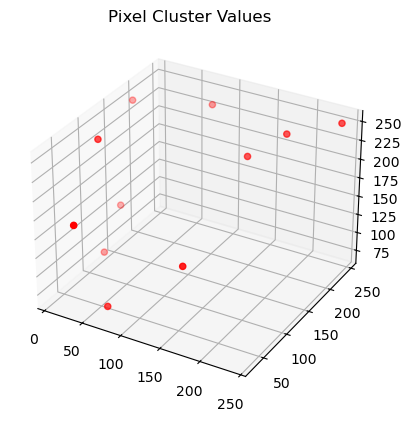

In [124]:
ax = plt.axes(projection="3d")
ax.scatter3D(img[:, :, 0], img[:, :, 1], img[:, :, 2])
ax.set_title("Pixel Values ")
plt.show()

ax = plt.axes(projection="3d")
ax.set_title("Pixel Cluster Values  ")
ax.scatter3D(
    cluster_int8[:, 0], cluster_int8[:, 1], cluster_int8[:, 2], color="red"
)
plt.show()

We can assign each data point to the cluster value and reshape it back  to a Rectangular image. 


In [ ]:
result = np.zeros(
    X.shape, dtype=np.uint8
)  # Create an empty array to store the clustered pixel values

for label in np.unique(labeled):
    result[labeled == label, :] = cluster_int8[label, :]


result = result.reshape(img.shape)

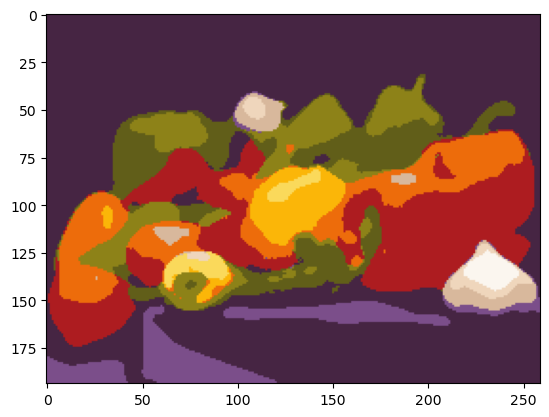

In [126]:
plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
plt.show()

We now plot each cluster, as a cluster value, and we see that each cluster corresponds to a different object. 


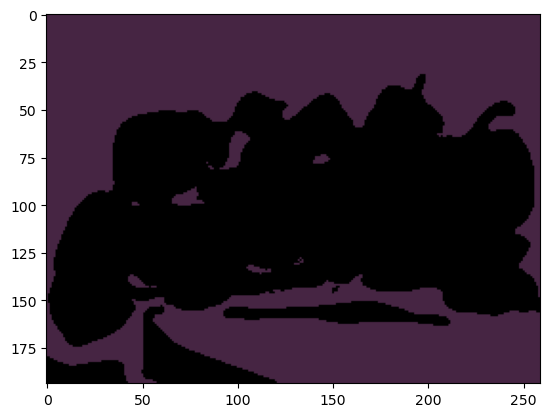

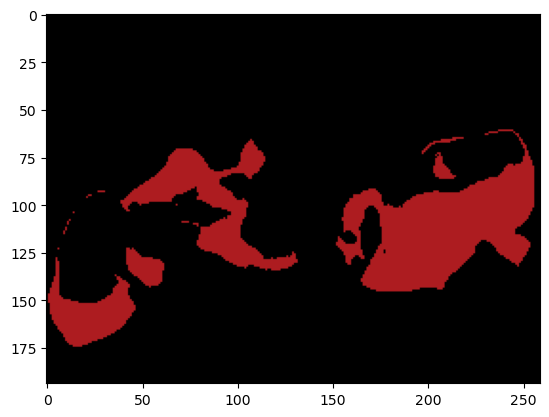

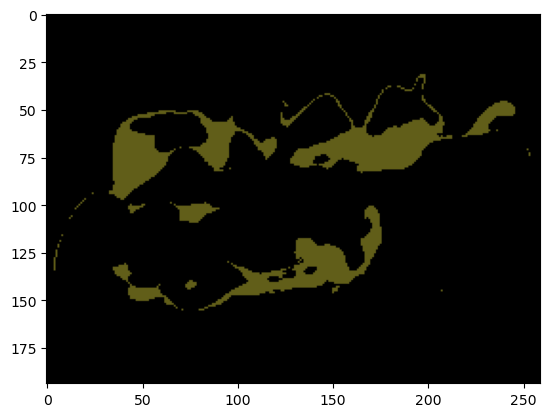

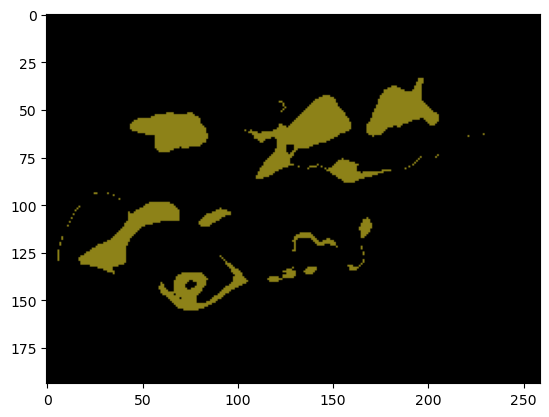

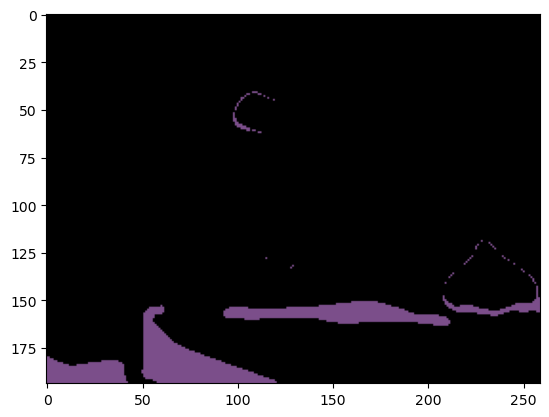

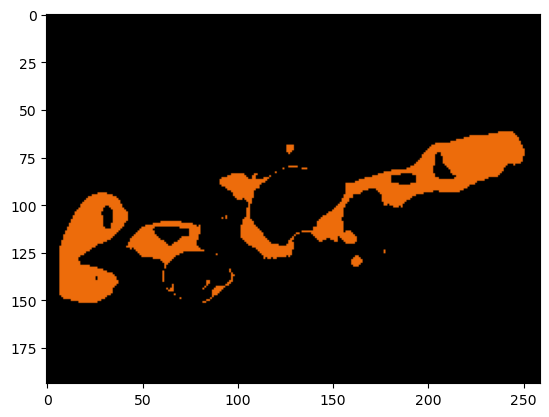

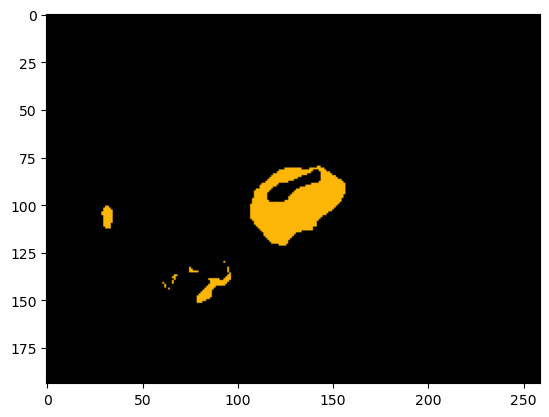

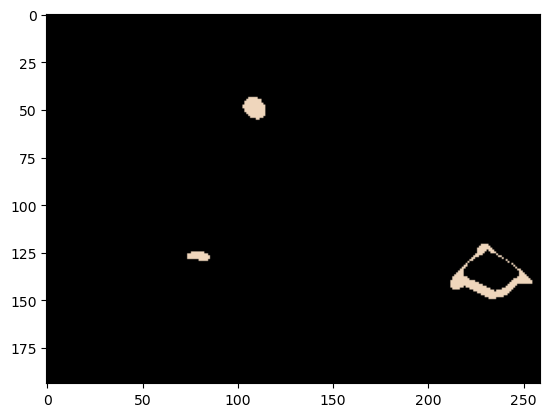

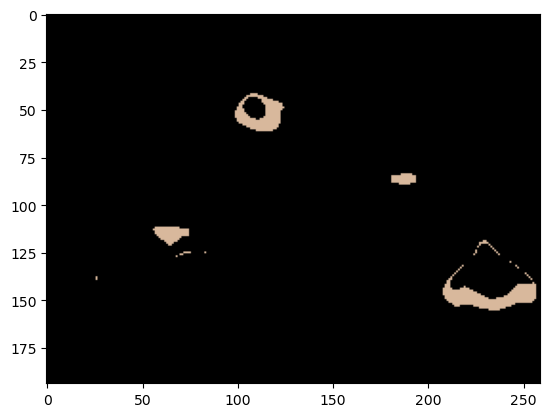

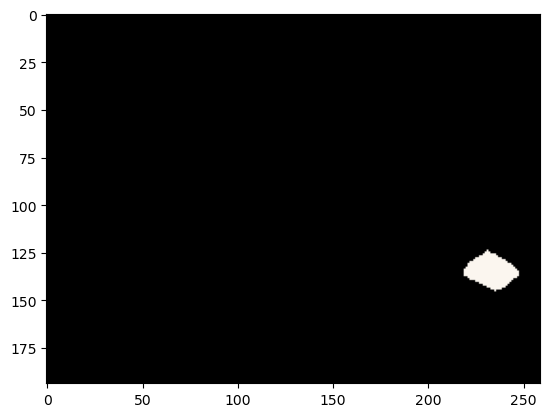

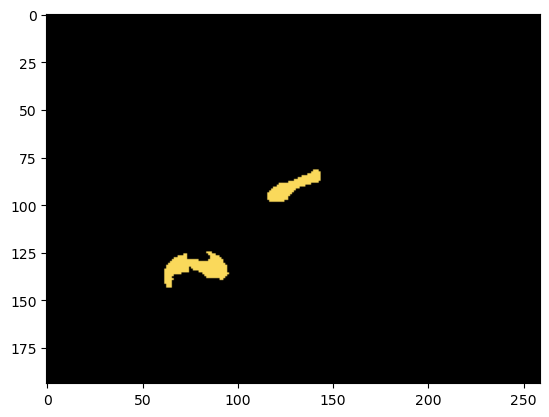

In [127]:
for label in np.unique(labeled):
    result = np.zeros(X.shape, dtype=np.uint8)
    result[labeled == label, :] = cluster_int8[label, :]
    plt.imshow(cv.cvtColor(result.reshape(img.shape), cv.COLOR_BGR2RGB))
    plt.show()

Therefore, we have classified our images according to their different vegetable types, using the Mean Shift Clustering.


## **Exercises**


### **Exercise 1 - Repeat the above image segmentation process for a new image on the internet**


Run the cell below to download the image from the web:


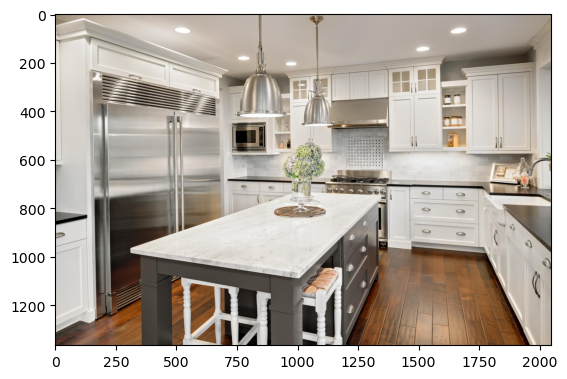

In [128]:
import requests

url = "https://www.plastform.ca/wp-content/themes/plastform/images/slider-image-2.jpg"
name = "my_file.jpg"

with open(name, "wb") as file:
    file.write(requests.get(url, stream=True).content)

img = cv.imread(name)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.show()

Now it's your turn to play around with the **MeanShift** algorithm.


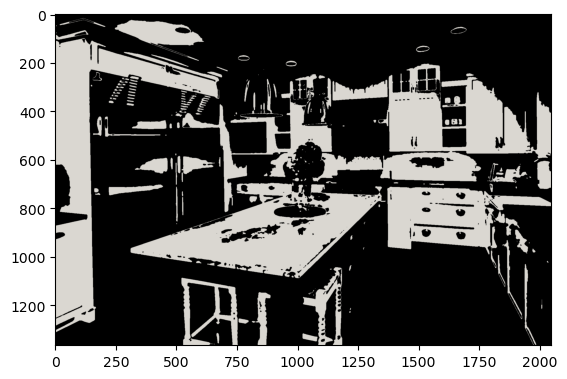

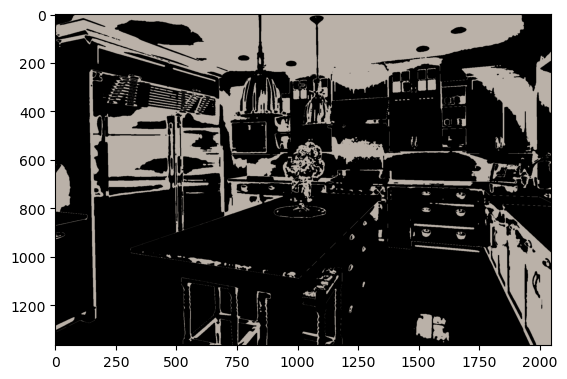

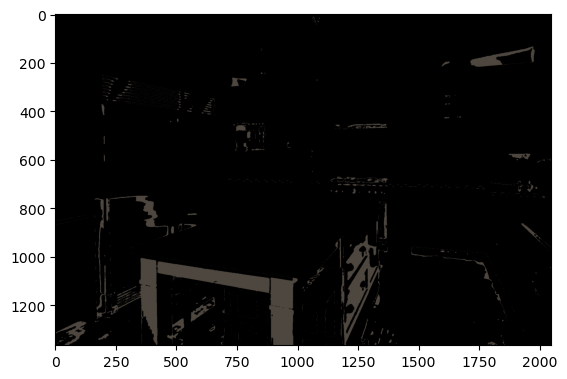

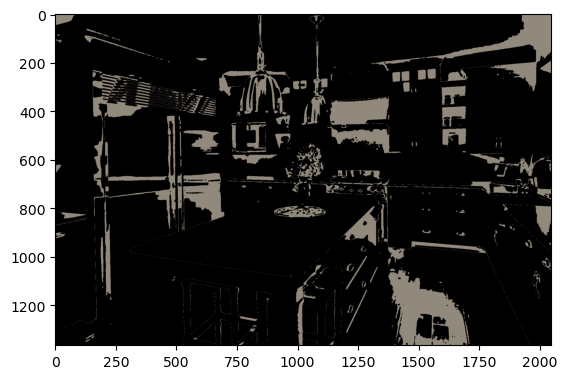

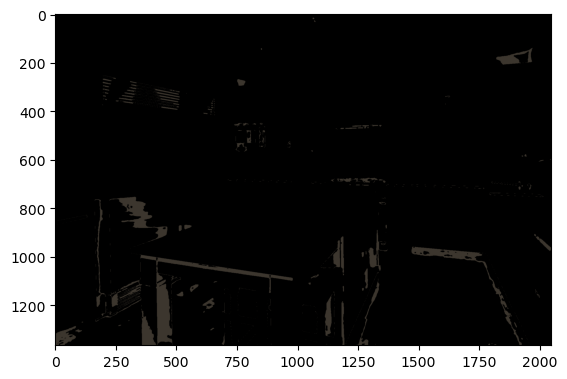

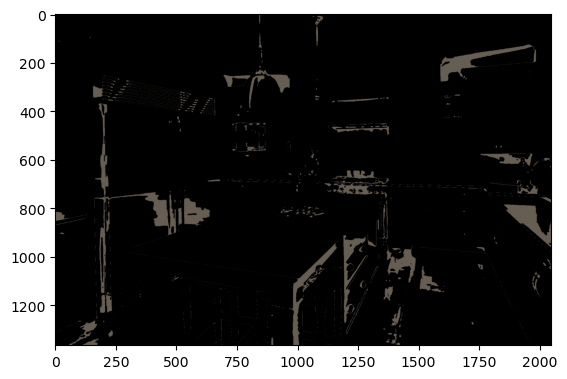

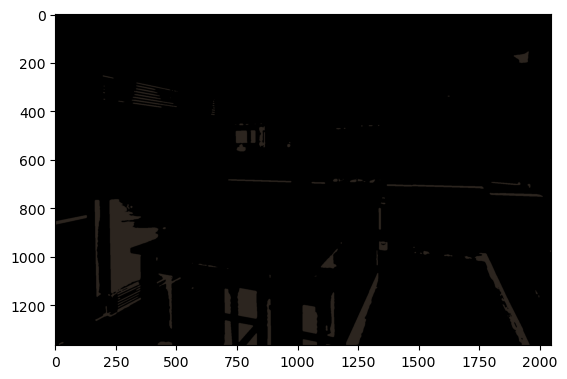

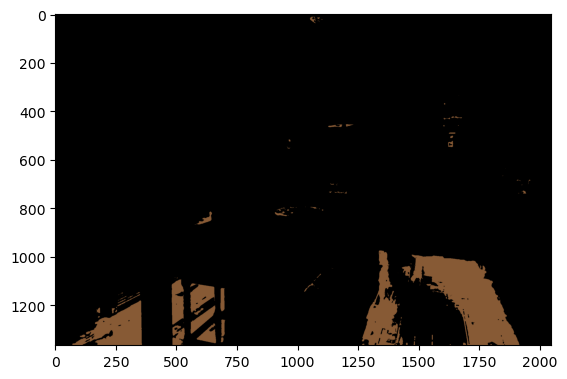

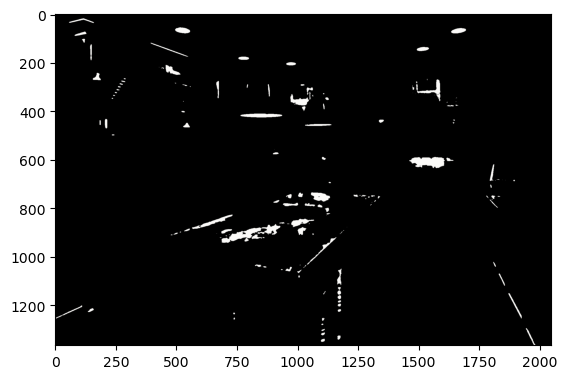

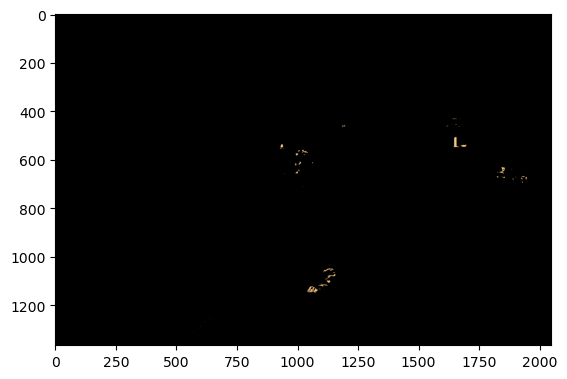

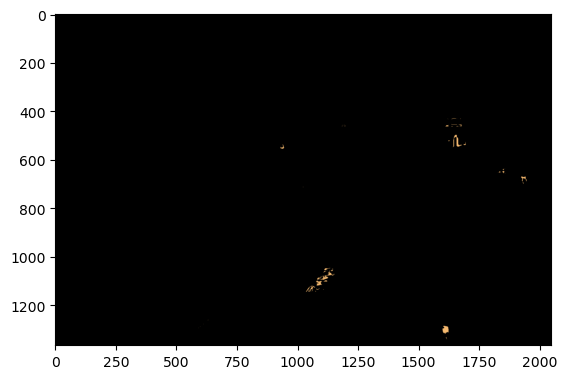

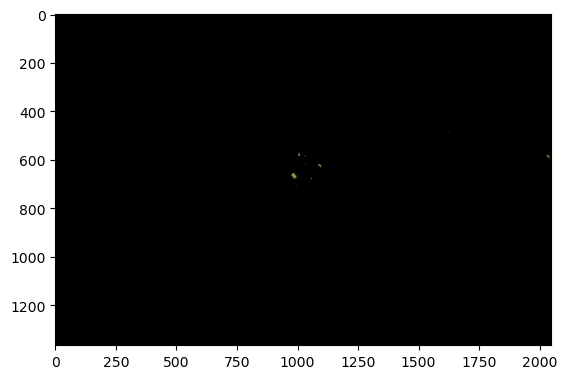

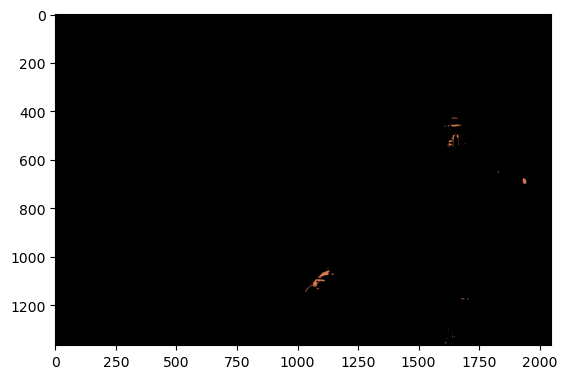

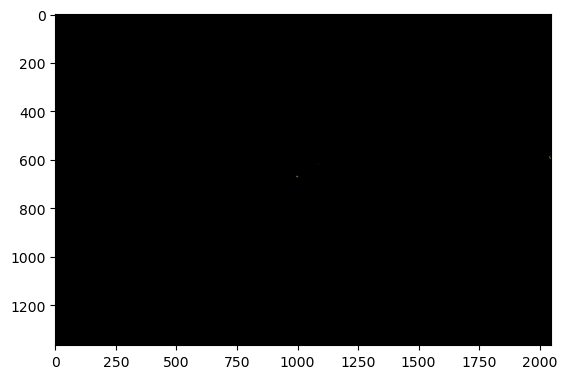

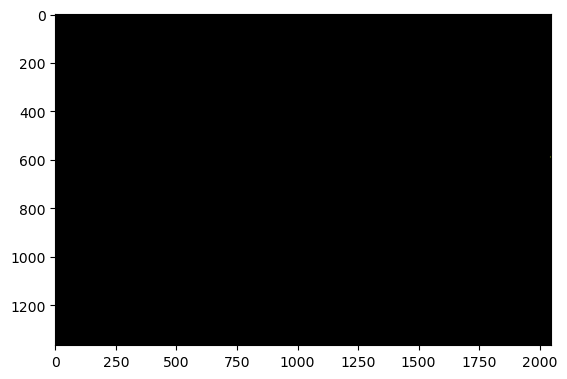

In [129]:
# TO DO
img = cv.medianBlur(img, 7)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
X = img.reshape((-1, 3))
X = np.float32(X)
bandwidth = estimate_bandwidth(X, quantile=0.06, n_samples=3000)
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X)
labeled = ms.labels_
cluster_int8 = np.uint8(ms.cluster_centers_)
result = np.zeros(X.shape, dtype=np.uint8)
labeled = ms.labels_
result = np.zeros(X.shape, dtype=np.uint8)

for label in np.unique(labeled):
    result[labeled == label, :] = cluster_int8[label, :]

    cluster_int8[label]
result = result.reshape(img.shape)
plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))

for label in np.unique(labeled):
    result = np.zeros(X.shape, dtype=np.uint8)
    result[labeled == label, :] = cluster_int8[label, :]
    plt.imshow(cv.cvtColor(result.reshape(img.shape), cv.COLOR_BGR2RGB))
    plt.show()

### **Exercise 2 - Mean Shift Applied to the Titanic Dataset**


On April 15, 1912, the  Titanic collided with an iceberg and sank. When the Titanic sank, it killed 1502 out of 2224 passengers and crew. In this section you will apply Mean-Shift clustering on features such as age, gender, class, etc. We will then determine if there is a relationship between survival and the different clusters. The following table summarizes the data:


<table>
<tbody>
<tr><th><b>Variable</b></th><th><b>Definition</b></th><th><b>Key</b></th></tr>
<tr>
<td>survival</td>
<td>Survival</td>
<td>0 = No, 1 = Yes</td>
</tr>
<tr>
<td>pclass</td>
<td>Ticket class</td>
<td>1 = 1st, 2 = 2nd, 3 = 3rd</td>
</tr>
<tr>
<td>sex</td>
<td>Sex</td>
<td></td>
</tr>
<tr>
<td>Age</td>
<td>Age in years</td>
<td></td>
</tr>
<tr>
<td>sibsp</td>
<td># of siblings / spouses aboard the Titanic</td>
<td></td>
</tr>
<tr>
<td>parch</td>
<td># of parents / children aboard the Titanic</td>
<td></td>
</tr>
<tr>
<td>ticket</td>
<td>Ticket number</td>
<td></td>
</tr>
<tr>
<td>fare</td>
<td>Passenger fare</td>
<td></td>
</tr>
<tr>
<td>cabin</td>
<td>Cabin number</td>
<td></td>
</tr>
<tr>
<td>embarked</td>
<td>Port of Embarkation</td>
<td>C = Cherbourg, Q = Queenstown, S = Southampton</td>
</tr>
</tbody>
</table>


#### **Data Pre-Processing:**


Let’s load the dataset.  


In [130]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%202/titanic.csv"
df = pd.read_csv(urlopen(url))
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


We can drop the following columns <code>'Name','Ticket','Cabin','PassengerId','Embarked' </code> for simplicity.


In [131]:
df = df.drop(columns=["Name", "Ticket", "Cabin", "PassengerId", "Embarked"])

We will assign "0" to "female" sex, and "1" to "male" sex, known as feature binarization. 


In [132]:
df.loc[df["Sex"] != "male", "Sex"] = 0
df.loc[df["Sex"] == "male", "Sex"] = 1

In [133]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,1,22.0,1,0,7.2500
1,1,1,0,38.0,1,0,71.2833
2,1,3,0,26.0,0,0,7.9250
3,1,1,0,35.0,1,0,53.1000
4,0,3,1,35.0,0,0,8.0500


We will check for missing values.   


In [134]:
df.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
dtype: int64

Here, we replace the  missing values in age, with the average age.


In [135]:
df["Age"].fillna(df["Age"].mean(), inplace=True)

We will assign the dataframe to X, for clustering, and drop our target, the <code>Survival</code>  column. 


In [136]:
X = df.drop(columns=["Survived"])

Now, we will standardize the data  <code>X</code>:


In [137]:
X = df.apply(lambda x: (x - x.mean()) / (x.std() + 0.0000001), axis=0)

In [138]:
X.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,-0.788829,0.826913,0.737281,-0.592148,0.432550,-0.473408,-0.502163
1,1.266278,-1.565228,-1.354812,0.638430,0.432550,-0.473408,0.786404
2,1.266278,0.826913,-1.354812,-0.284503,-0.474279,-0.473408,-0.488580
3,1.266278,-1.565228,-1.354812,0.407697,0.432550,-0.473408,0.420494
4,-0.788829,0.826913,0.737281,0.407697,-0.474279,-0.473408,-0.486064


#### **Apply the mean-shift to Titanic data frame X:**


To apply the mean-shift algorithm to X, first use the <code>estimate_bandwidth</code> function to estimate the value for the bandwidth parameter. Then create a MeanShift object and fit it to X:


In [139]:
# TO DO
bandwidth = estimate_bandwidth(X)
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X)

,bandwidth,2.6395838673142618
,seeds,None
,bin_seeding,True
,min_bin_freq,1
,cluster_all,True
,n_jobs,None
,max_iter,300


Next, we append the clusters to the dataset for analysis. 


In [140]:
X["cluster"] = ms.labels_
df["cluster"] = ms.labels_

Now, we group by clusters, to see that certain clusters have a larger chance of survival. 


In [141]:
df.groupby("cluster").mean().sort_values(by=["Survived"], ascending=False)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
cluster,,,,,,,
5,1.000000,1.000000,0.666667,35.333333,0.000000,0.333333,512.329200
4,0.750000,1.000000,0.285714,27.822048,0.857143,1.250000,195.894643
0,0.381313,2.313131,0.676768,30.734477,0.285354,0.199495,23.992865
3,0.307692,2.846154,0.153846,38.692308,0.769231,4.230769,29.377562
1,0.260870,2.913043,0.5,8.745575,3.239130,1.543478,30.968026
2,0.000000,3.000000,0.571429,29.699118,8.000000,2.000000,69.550000
6,0.000000,1.000000,1.0,61.000000,0.500000,3.000000,188.137500


From the table above, we see that there are 7 clusters generated by the mean-shift analysis, each cluster contains the average percentage of survivors. 

For instance, cluster 5, has 100 % of survivors, with the average age of 35.3, passengers belonging to the 1st class, and the passengers who paid the highest fare, 512.33 per ticket. Interestingly, Cluster 6, has 0 % of survivors, with the average age of 61, also belonging to the 1st class and in the mid-range ticket fare. It is not surprising that the highest odds for survival were held by the younger and richer groups of passengers.


## **How Mean Shift Works (Optional)**


Mean Shift is a clustering algorithm that finds regions where data points are highly concentrated.

The basic idea is simple. Place a window around a point, compute the weighted average of the data points near that window, and move the window center to that average. Repeat this process until the center barely moves.

Because nearby points receive the largest weights, each window moves toward a nearby dense region. Points whose windows end at the same dense region are assigned to the same cluster.

Unlike K-Means, Mean Shift does not require specifying the number of clusters in advance. The algorithm automatically discovers clusters from the data distribution.

The next two subsections separate the ideas clearly. First, Kernel Density Estimation (KDE) explains how to describe dense regions mathematically. Then Mean Shift uses that density view to move points toward cluster centers.


### **Kernel Density Estimation**


Suppose we have $n$ data points $\{x_1, x_2, \ldots, x_n\}$ in $D$ dimensions.

A histogram can estimate density, but it depends heavily on the chosen bin size and bin locations. KDE gives a smoother estimate by placing a small smooth bump, called a kernel, on each data point.

When many kernels overlap, the estimated density is high. When few kernels overlap, the estimated density is low.

A commonly used kernel is the Gaussian kernel. In one dimension, centered at $x_i$, it can be written as:

$$
K_h(x - x_i) = \frac{1}{h\sqrt{2\pi}}\exp\left(-\frac{(x - x_i)^2}{2h^2}\right)
$$

where:

- $x_i$ is one data point
- $x$ is the location where we evaluate density
- $h$ is the bandwidth, or window width

For $D$ dimensions, the KDE estimate can be written more generally as:

$$
\hat{f}_h(x) = \frac{1}{n}\sum_{i=1}^{n} K_h(x - x_i)
$$

Equivalently, if $K(u)$ is an unscaled kernel, then:

$$
K_h(x - x_i) = \frac{1}{h^D}K\left(\frac{x - x_i}{h}\right)
$$

The bandwidth $h$ controls how wide each kernel is. A small $h$ keeps the estimate very local and may reveal small clusters, but it can be noisy. A large $h$ makes the estimate smoother, but nearby clusters may merge.


For the examples below, we code a one-dimensional Gaussian kernel as a function of the distance $d = |x - x_i|$ and the bandwidth $h$:


In [142]:
def gaussian(d, h):
    return np.exp(-0.5 * ((d / h)) ** 2) / (h * math.sqrt(2 * math.pi))

There are many possible kernels. We use the Gaussian kernel because it is smooth and easy to interpret.


Now evaluate the kernel for one sample point, $x_1 = 1$, which we store as <code>s</code>. We evaluate the kernel on the interval $-2 < x < 4$ and compare two bandwidths, $h=1$ and $h=3$.


In [143]:
s = 1  # a sample point

x = np.linspace(-2, 4, num=200)
dist = np.sqrt(((x - s) ** 2))
kernel_1 = gaussian(dist, 1)
kernel_2 = gaussian(dist, 3)

The plot below shows how the bandwidth changes the shape of the kernel. The histogram marks the original sample point.


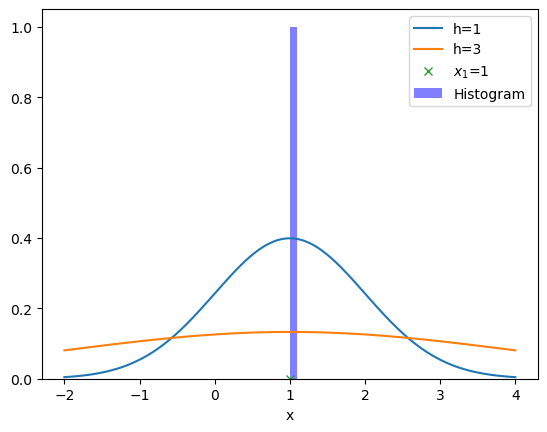

In [144]:
plt.plot(x, kernel_1, label="h=1")
plt.plot(x, kernel_2, label="h=3")
plt.plot(s, 0, "x", label="$x_{1}$=1")
plt.hist(s, 10, facecolor="blue", alpha=0.5, label="Histogram")
plt.xlabel("x")
plt.legend()
plt.show()

Locations close to $x_1 = 1$ receive large kernel values. Locations far from $x_1$ receive values close to 0. A larger bandwidth spreads the influence of the point across a wider region.


For many samples, KDE adds the kernel contribution from every point:


$$
\hat{f}_h(x) = \frac{1}{n}\sum_{i=1}^{n}K_h(x - x_i)
$$


In Python, we estimate the density for sample points stored in <code>S</code> over a grid of values <code>x</code>. The function below adds one Gaussian kernel per sample point and normalizes the result for plotting.


In [145]:
def kernel_density(S, x, h=1):

    density = np.zeros((200))
    for s in S:
        # Determine the distance and kernel for each point
        dist = np.sqrt(((x - s) ** 2))
        kernel = gaussian(dist, h)
        # Find the sum
        density += kernel
    # Normalize the sum
    density = density / density.sum()

    return density

Consider the following data points:  


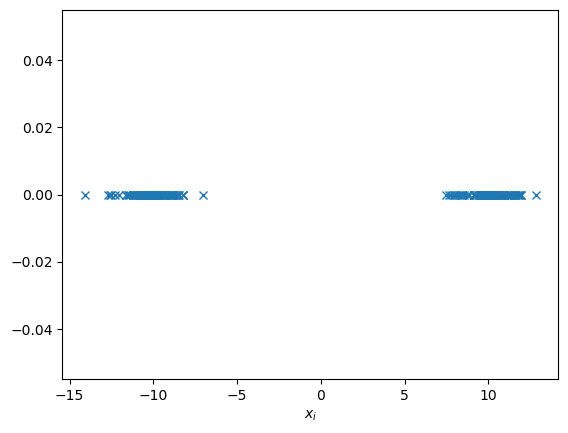

In [146]:
S = np.zeros((200))
S[0:100] = np.random.normal(-10, 1, 100)
S[100:200] = np.random.normal(10, 1, 100)
plt.plot(S, np.zeros((200)), "x")
plt.xlabel("$x_{i}$")
plt.show()

Next, generate the density over a grid of $x$ values that covers the sample points.


In [147]:
x = np.linspace(S.min() - 3, S.max() + 3, num=200)
density = kernel_density(S, x)

The density plot has two clear peaks. These peaks are the high-density regions that Mean Shift will try to find.


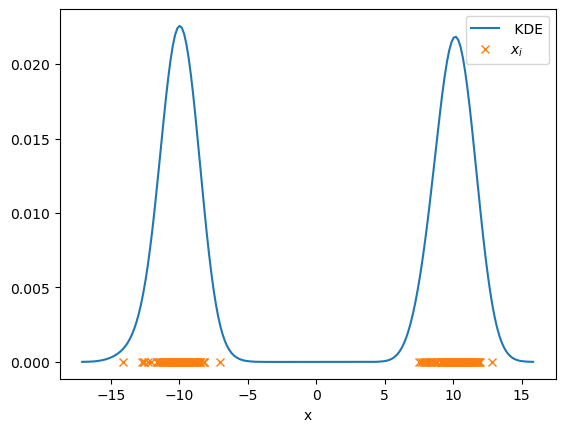

In [148]:
plt.plot(x, density, label=" KDE")
plt.plot(S, np.zeros((200, 1)), "x", label="$x_{i}$")
plt.xlabel("x")
plt.legend()
plt.show()

One way to find these peaks is gradient ascent: start from a point and repeatedly move in the direction where the KDE increases fastest.


$$
\hat{x}_i^{(t+1)} = \hat{x}_i^{(t)} + \eta \nabla \hat{f}_h\left(\hat{x}_i^{(t)}\right)
$$


Here, $\hat{x}_i^{(t)}$ is the current position of the point that started at $x_i$, $t$ is the iteration number, $\eta$ is the step size, and $\nabla \hat{f}_h$ is the gradient of the KDE.


Mean Shift gives a practical update rule for moving toward the same density peaks without manually choosing a gradient-ascent step size for each move.


### **Mean Shift From Scratch**


Mean Shift can be understood as a simple way to climb the KDE surface toward a local density peak.

Start with a current position $x$. Look at the data points around $x$. Points closer to $x$ should have more influence than points farther away, so each point receives the kernel weight $K_h(x - x_i)$.

The weighted average of the data points is:

$$
\mu_h(x) = \frac{\sum_{i=1}^{n}K_h(x - x_i)x_i}{\sum_{i=1}^{n}K_h(x - x_i)}
$$

This average, $\mu_h(x)$, is the center of nearby points under the kernel weights. The mean shift vector is the difference between this weighted average and the current position:

$$
m_h(x) = \mu_h(x) - x
$$

Substituting the weighted average gives:

$$
m_h(x) = \frac{\sum_{i=1}^{n}K_h(x - x_i)x_i}{\sum_{i=1}^{n}K_h(x - x_i)} - x
$$

The vector $m_h(x)$ points from the current position toward a nearby region with higher density. Mean Shift updates the position by adding this vector:

$$
x^{(t+1)} = x^{(t)} + m_h\left(x^{(t)}\right)
$$

Because $x^{(t)} + m_h(x^{(t)})$ is exactly the weighted average, the update can also be written as:

$$
x^{(t+1)} = \frac{\sum_{i=1}^{n}K_h\left(x^{(t)} - x_i\right)x_i}{\sum_{i=1}^{n}K_h\left(x^{(t)} - x_i\right)}
$$

Repeat this update until the position stops changing. Points that converge to the same final location are assigned to the same cluster.

The bandwidth $h$ is the key parameter:

- Small $h$ focuses on very local neighborhoods and can find smaller clusters, but it is more sensitive to noise.
- Large $h$ uses wider neighborhoods and gives smoother clusters, but it may merge nearby groups.

For the one-dimensional example, we can compute a mean shift value for each grid location. The code below applies the same weighted-average rule with bandwidth $h=2.5$.


In [149]:
mean_shift = np.zeros_like(x)

for i, x_current in enumerate(x):
    dist = np.sqrt((x_current - S) ** 2)
    weight = gaussian(dist, 2.5)
    weighted_mean = (weight * S).sum() / weight.sum()
    mean_shift[i] = weighted_mean - x_current

Overlaying the mean shift values on the density plot shows that the arrows point toward the two density peaks.


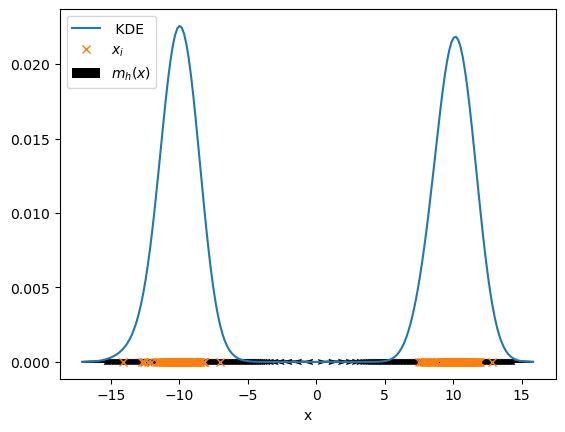

In [150]:
plt.plot(x, density, label=" KDE")
plt.plot(S, np.zeros((200, 1)), "x", label="$x_{i}$")
plt.quiver(
    x,
    np.zeros((200, 1)),
    mean_shift,
    np.zeros((200, 1)),
    units="width",
    label="$m_{h}(x)$",
)
plt.xlabel("x")
plt.legend()
plt.show()

The update rule used by Mean Shift is:


$$
\hat{x}_i^{(t+1)} = \hat{x}_i^{(t)} + m_h\left(\hat{x}_i^{(t)}\right)
$$


Using the definition of $m_h$, this simplifies to the weighted average of nearby points:


$$
\hat{x}_i^{(t+1)} = \frac{\sum_{j=1}^{n}K_h\left(\hat{x}_i^{(t)} - x_j\right)x_j}{\sum_{j=1}^{n}K_h\left(\hat{x}_i^{(t)} - x_j\right)}
$$

We use $j$ in the sums because $i$ identifies the point being updated, while $j$ indexes all data points that contribute to the weighted average.


Now run three Mean Shift iterations. Each point moves toward one of the two density peaks.


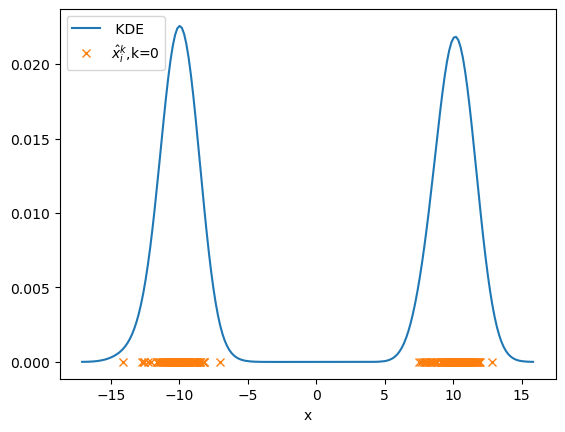

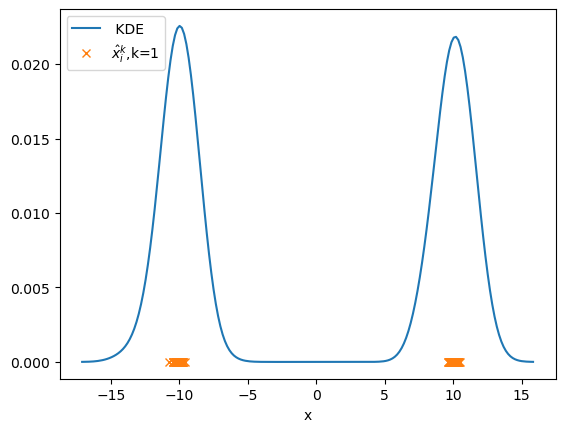

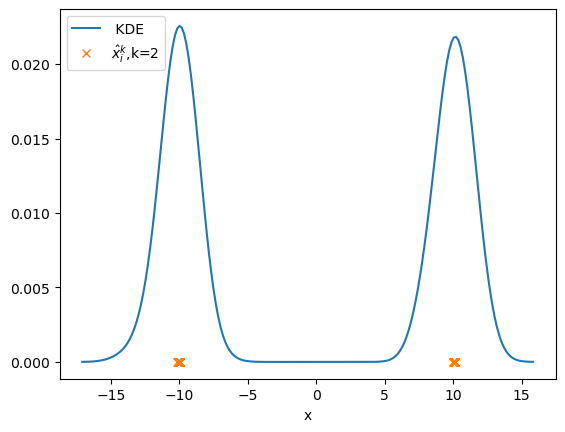

In [151]:
Xhat = np.copy(S.reshape(-1, 1))
S_ = S.reshape(-1, 1)


for k in range(3):
    plt.plot(x, density, label=" KDE")
    plt.plot(Xhat, np.zeros((200, 1)), "x", label="$\hat{x}^{k}_i$,k=" + str(k))
    plt.xlabel("x")
    plt.legend()
    plt.show()

    for i, xhat in enumerate(Xhat):
        dist = np.sqrt(((xhat - S_) ** 2).sum(1))
        weight = gaussian(dist, 2.5)
        Xhat[i] = (weight.reshape(-1, 1) * S_).sum(0) / weight.sum()

After several iterations, many points have moved close to the same peak. Rounding the final positions gives a quick view of the discovered cluster centers.


In [152]:
np.unique(Xhat.astype(int))

array([-10,  10])

## **Authors**


<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01">Joseph Santarcangelo </a> has a Ph.D. in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.

Su Wu

### **Other Contributors**


[Roxanne Li](https://www.linkedin.com/in/roxanne-li/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01) is a Data Science intern at IBM Skills Network, entering level-5 study in the Mathematics & Statistics undergraduate Coop program at McMaster University.


## **Change Log**


<table>
    <tr>
        <th>Date (YYYY-MM-DD)</th>
        <th>Version</th>
        <th>Changed By</th>
        <th>Change Description</th>
    </tr>
    <tr>
        <td>2022-02-03</td>
        <td>0.1</td>
        <td>Joseph</td>
        <td>First commit</td>
    </tr>
    <tr>
        <td>2022-02-15</td>
        <td>0.1</td>
        <td>Svitlana Kramar</td>
        <td>Edited Introductions</td>
    </tr>
    <tr>
        <td>2022-05-25</td>
        <td>0.2</td>
        <td>Roxanne Li</td>
        <td>Review and edit</td>
    </tr>
     <tr>
        <td>2022-07-18</td>
        <td>0.2</td>
        <td>Svitlana Kramar</td>
        <td>Final Edit</td>
    </tr>
    <tr>
        <td>2026-05-12</td>
        <td>0.3</td>
        <td>Su Wu</td>
        <td>Documentation and code edits</td>
    </tr>
</table>


Copyright © 2020 IBM Corporation. All rights reserved.
